# Titanic Survival Prediction
## Professional Machine Learning Classification Project

This notebook predicts passenger survival using a clean, reproducible machine-learning workflow. It improves the original project by preventing data leakage, using reusable preprocessing pipelines, comparing models with cross-validation, tuning a Random Forest, and evaluating the final model on an untouched test set.

**Workflow:** Load Data → Data Quality Assessment → Survival-Focused EDA → Feature Engineering → Train-Test Split → Preprocessing Pipeline → Model Training → Cross-Validation → Test Evaluation → Hyperparameter Tuning → Final Prediction and Model Saving

# 1. Project Overview and Objective

### Objective
Build a reliable binary-classification workflow that predicts whether a Titanic passenger survived.

### Main improvements
- Load and inspect the dataset only once.
- Keep categorical values readable and process them inside a pipeline.
- Split the data before fitting imputers, encoders, or scalers.
- Compare Logistic Regression, Decision Tree, and Random Forest using the same data split.
- Use 5-fold cross-validation with F1-score.
- Tune Random Forest using `GridSearchCV`.
- Save the complete preprocessing-and-model pipeline for reuse.

# 2. Import Libraries

In [1]:
from pathlib import Path
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# 3. Load Dataset

In [2]:
DATA_FILENAME = "Titanic-Dataset.csv"
candidate_paths = [
    Path(DATA_FILENAME),
    Path.cwd() / DATA_FILENAME,
    Path.cwd().parent / DATA_FILENAME,
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"{DATA_FILENAME} was not found. Place it in the same folder as the notebook, "
        "then restart the kernel and run all cells."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
display(df.head())

Dataset path: C:\Users\layan\Downloads\archive (2)\archive (1)\Titanic-Dataset.csv
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Data Quality Assessment

In [3]:
print("Dataset information:\n")
df.info()

print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("Duplicated rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values by column:


,Missing Values
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Duplicated rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Data-quality observations
- `Age`, `Cabin`, and `Embarked` contain missing values.
- `Cabin` has a very high missing-value rate, so it is not used as a model feature.
- Missing values in selected features are handled **inside the preprocessing pipeline**, preventing leakage from the test set.

# 5. Exploratory Data Analysis

## 5.1 Survival Rate by Gender

Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object


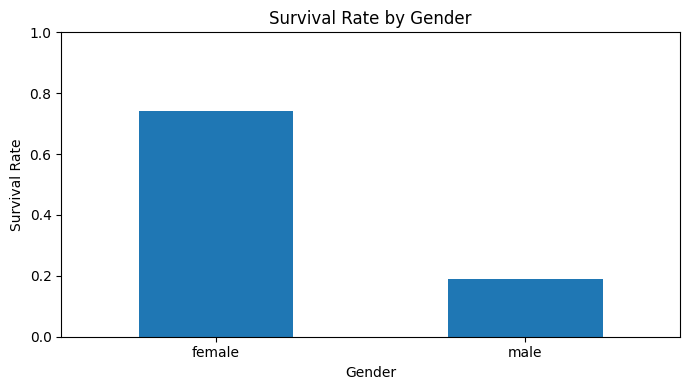

In [4]:
survival_by_sex = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print((survival_by_sex * 100).round(1).astype(str) + "%")

survival_by_sex.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Female passengers had a much higher survival rate (about 74%) than male passengers (about 19%). Gender is therefore strongly associated with survival in this dataset.

## 5.2 Survival Rate by Passenger Class

Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object


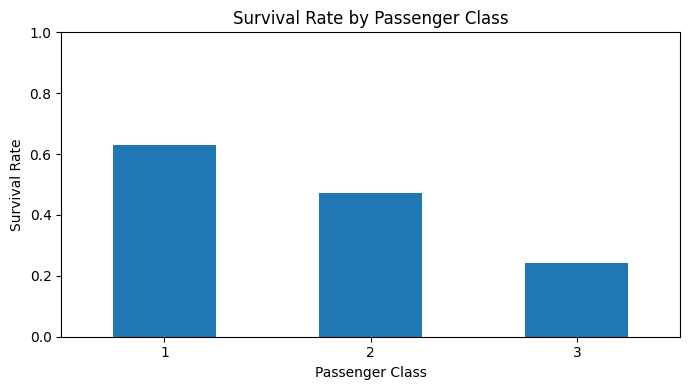

In [5]:
survival_by_class = df.groupby("Pclass")["Survived"].mean().sort_index()
print((survival_by_class * 100).round(1).astype(str) + "%")

survival_by_class.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** First-class passengers had the highest survival rate, while third-class passengers had the lowest. Passenger class appears to capture important differences in access, location, and evacuation opportunity.

## 5.3 Survival Rate by Embarkation Port

Embarked
C    55.4%
Q    39.0%
S    33.7%
Name: Survived, dtype: object


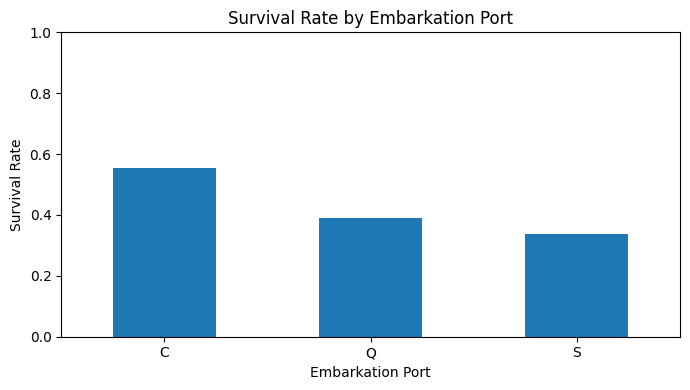

In [6]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
print((survival_by_embarked * 100).round(1).astype(str) + "%")

survival_by_embarked.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.xlabel("Embarkation Port")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Passengers who embarked at Cherbourg (`C`) had the highest survival rate. This relationship may partly reflect differences in passenger class and fare rather than the port alone.

## 5.4 Age Distribution by Survival

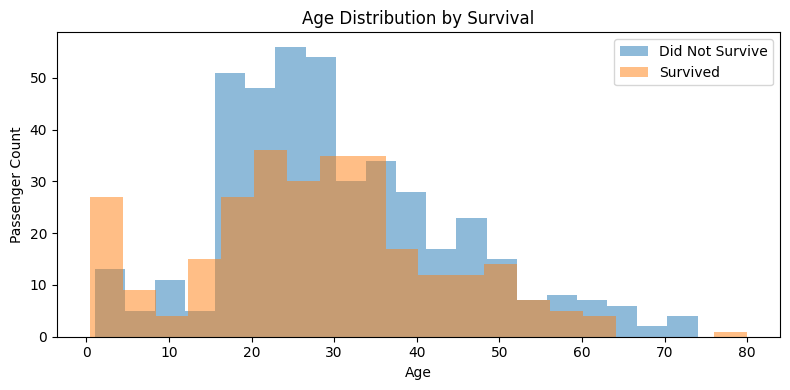

In [7]:
df.loc[df["Survived"] == 0, "Age"].plot(
    kind="hist", bins=20, alpha=0.5, figsize=(8, 4), label="Did Not Survive"
)
df.loc[df["Survived"] == 1, "Age"].plot(
    kind="hist", bins=20, alpha=0.5, label="Survived"
)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The two age distributions overlap substantially, so age alone cannot explain survival. However, younger children appear more represented among survivors than among non-survivors.

# 6. Feature Engineering

In [8]:
# Family-related features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Extract a passenger title from Name, then combine uncommon titles into "Rare"
df["Title"] = (
    df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
    .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
)

common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

display(df[["Name", "FamilySize", "IsAlone", "Title"]].head())
print("\nTitle counts:")
display(df["Title"].value_counts().to_frame("Count"))

,Name,FamilySize,IsAlone,Title
0,"Braund, Mr. Owen Harris",2,0,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Mrs
2,"Heikkinen, Miss. Laina",1,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Mrs
4,"Allen, Mr. William Henry",1,1,Mr



Title counts:


,Count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


`FamilySize` combines parents, children, siblings, and spouses into one interpretable measure. `IsAlone` identifies passengers traveling without family, while `Title` summarizes social and demographic information contained in the passenger name.

# 7. Define Features and Target

In [9]:
base_feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

title_feature_columns = base_feature_columns + ["Title"]
y = df["Survived"]

print("Base feature count:", len(base_feature_columns))
print("Feature count with Title:", len(title_feature_columns))
print("Target shape:", y.shape)

Base feature count: 9
Feature count with Title: 10
Target shape: (891,)


# 8. Train-Test Split

In [10]:
train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print("Training rows:", len(train_indices))
print("Testing rows:", len(test_indices))
print("Training survival rate:", f"{y_train.mean():.2%}")
print("Testing survival rate:", f"{y_test.mean():.2%}")

Training rows: 712
Testing rows: 179
Training survival rate: 38.34%
Testing survival rate: 38.55%


Using `stratify=y` preserves a similar survived/non-survived proportion in the training and testing sets. No imputer, encoder, or scaler is fitted before this split.

# 9. Preprocessing Pipeline

In [11]:
def build_preprocessor(feature_columns):
    """Create separate preprocessing pipelines for numerical and categorical features."""
    categorical_candidates = ["Sex", "Embarked", "Title"]
    categorical_features = [
        column for column in categorical_candidates if column in feature_columns
    ]
    numerical_features = [
        column for column in feature_columns if column not in categorical_features
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def build_model_pipeline(model, feature_columns):
    """Keep preprocessing and model training together in one reusable pipeline."""
    return Pipeline([
        ("preprocessor", build_preprocessor(feature_columns)),
        ("model", model),
    ])

The pipeline prevents data leakage because the median, most-frequent category, scaling values, and one-hot categories are learned only from each training fold or from the final training set.

# 10. Bonus Task — Compare Performance Before and After Adding Title

In [12]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_experiment_results = []

for experiment_name, feature_columns in {
    "Without Title": base_feature_columns,
    "With Title": title_feature_columns,
}.items():
    experiment_X_train = df.loc[train_indices, feature_columns]
    experiment_pipeline = build_model_pipeline(
        LogisticRegression(max_iter=1000, random_state=42),
        feature_columns,
    )
    experiment_scores = cross_val_score(
        experiment_pipeline,
        experiment_X_train,
        y_train,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=1,
    )
    feature_experiment_results.append({
        "Feature Set": experiment_name,
        "Mean CV F1": experiment_scores.mean(),
        "CV Standard Deviation": experiment_scores.std(),
    })

feature_experiment_df = pd.DataFrame(feature_experiment_results)
display(feature_experiment_df.sort_values("Mean CV F1", ascending=False))

use_title = (
    feature_experiment_df.loc[
        feature_experiment_df["Feature Set"] == "With Title", "Mean CV F1"
    ].iloc[0]
    >= feature_experiment_df.loc[
        feature_experiment_df["Feature Set"] == "Without Title", "Mean CV F1"
    ].iloc[0]
)

feature_columns = title_feature_columns if use_title else base_feature_columns
X_train = df.loc[train_indices, feature_columns]
X_test = df.loc[test_indices, feature_columns]

print("Selected feature set:", "With Title" if use_title else "Without Title")
print("Final features:", feature_columns)

,Feature Set,Mean CV F1,CV Standard Deviation
1,With Title,0.761008,0.027274
0,Without Title,0.729435,0.016930


Selected feature set: With Title
Final features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


**Interpretation:** Adding `Title` increases the mean cross-validation F1-score, so it is retained in the final feature set. The decision is based only on training-set cross-validation, not on test-set performance.

# 11. Model Creation

In [13]:
models = {
    "Logistic Regression": build_model_pipeline(
        LogisticRegression(max_iter=1000, random_state=42),
        feature_columns,
    ),
    "Decision Tree": build_model_pipeline(
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
        ),
        feature_columns,
    ),
    "Random Forest": build_model_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1,
        ),
        feature_columns,
    ),
}

print("Models created:", list(models.keys()))

Models created: ['Logistic Regression', 'Decision Tree', 'Random Forest']


# 12. Cross-Validation

In [14]:
cv_results = []

for model_name, model_pipeline in models.items():
    scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=1,
    )
    cv_results.append({
        "Model": model_name,
        "Mean CV F1": scores.mean(),
        "CV Standard Deviation": scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean CV F1", ascending=False)
    .reset_index(drop=True)
)
display(cv_results_df)

best_baseline_model_name = cv_results_df.iloc[0]["Model"]
print("Best baseline model by mean CV F1:", best_baseline_model_name)

,Model,Mean CV F1,CV Standard Deviation
0,Logistic Regression,0.761008,0.027274
1,Random Forest,0.737307,0.028074
2,Decision Tree,0.728175,0.020615


Best baseline model by mean CV F1: Logistic Regression


**Interpretation:** Logistic Regression has the strongest average baseline F1-score. The standard deviations are relatively small, indicating that performance is reasonably stable across the five folds. Cross-validation is more reliable than one split because every training observation is used for both training and validation across different folds.

# 13. Test Evaluation and Model Comparison

In [15]:
test_results = []
fitted_models = {}
model_predictions = {}

for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, y_train)
    predictions = model_pipeline.predict(X_test)
    probabilities = model_pipeline.predict_proba(X_test)[:, 1]

    fitted_models[model_name] = model_pipeline
    model_predictions[model_name] = predictions

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)
display(test_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.854749,0.841270,0.768116,0.803030,0.879447
1,Random Forest,0.821229,0.813559,0.695652,0.750000,0.855138
2,Decision Tree,0.787709,0.792453,0.608696,0.688525,0.836166


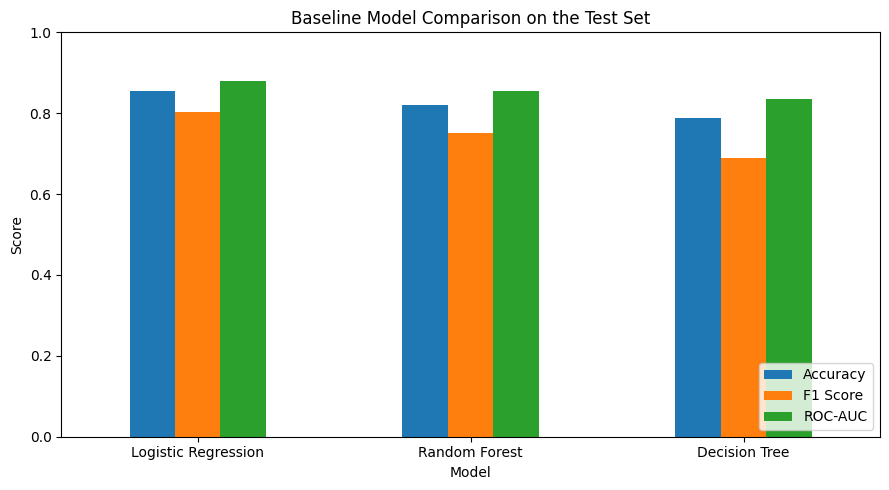

In [16]:
comparison_plot = test_results_df.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]]
comparison_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Baseline Model Comparison on the Test Set")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Logistic Regression performs best on this particular test split and also has the highest baseline cross-validation F1-score. Decision Tree has the weakest recall and F1-score, while Random Forest provides competitive but slightly lower baseline results.

## 13.1 Detailed Evaluation of the Best Baseline Model

In [17]:
best_baseline_model = fitted_models[best_baseline_model_name]
best_baseline_predictions = model_predictions[best_baseline_model_name]

print("Best baseline model:", best_baseline_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_baseline_predictions, digits=3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_baseline_predictions))

Best baseline model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0      0.862     0.909     0.885       110
           1      0.841     0.768     0.803        69

    accuracy                          0.855       179
   macro avg      0.852     0.839     0.844       179
weighted avg      0.854     0.855     0.853       179

Confusion Matrix:
[[100  10]
 [ 16  53]]


# 14. Hyperparameter Tuning

In [18]:
parameter_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
}

forest_tuning_pipeline = build_model_pipeline(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    feature_columns,
)

grid_search = GridSearchCV(
    estimator=forest_tuning_pipeline,
    param_grid=parameter_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best cross-validation F1: 0.7699


The grid is intentionally compact because the Titanic dataset is small. It tests multiple values for the main tree-depth, split, and ensemble-size parameters while keeping the notebook practical to run. Random Forest is tuned because the feedback specifically requires `GridSearchCV` for this model. The tuned model will still be compared with the strongest baseline before the final model is selected.

## 14.1 Evaluate the Tuned Model on the Untouched Test Set

In [19]:
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)
tuned_probabilities = tuned_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_predictions)
tuned_precision = precision_score(y_test, tuned_predictions, zero_division=0)
tuned_recall = recall_score(y_test, tuned_predictions, zero_division=0)
tuned_f1 = f1_score(y_test, tuned_predictions, zero_division=0)
tuned_roc_auc = roc_auc_score(y_test, tuned_probabilities)

print(f"Tuned Accuracy:  {tuned_accuracy:.4f}")
print(f"Tuned Precision: {tuned_precision:.4f}")
print(f"Tuned Recall:    {tuned_recall:.4f}")
print(f"Tuned F1:        {tuned_f1:.4f}")
print(f"Tuned ROC-AUC:   {tuned_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tuned_predictions, digits=3))

Tuned Accuracy:  0.8324
Tuned Precision: 0.8095
Tuned Recall:    0.7391
Tuned F1:        0.7727
Tuned ROC-AUC:   0.8532

Classification Report:
              precision    recall  f1-score   support

           0      0.845     0.891     0.867       110
           1      0.810     0.739     0.773        69

    accuracy                          0.832       179
   macro avg      0.827     0.815     0.820       179
weighted avg      0.831     0.832     0.831       179



## 14.2 Final Model Selection

The tuned Random Forest must be evaluated on the untouched test set, but tuning it does not automatically make it the final model. The final choice is based on cross-validation stability and test-set metrics.

In [20]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression (Baseline)",
        "Mean CV F1": cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression", "Mean CV F1"
        ].iloc[0],
        "Test Accuracy": test_results_df.loc[
            test_results_df["Model"] == "Logistic Regression", "Accuracy"
        ].iloc[0],
        "Test F1": test_results_df.loc[
            test_results_df["Model"] == "Logistic Regression", "F1 Score"
        ].iloc[0],
        "Test ROC-AUC": test_results_df.loc[
            test_results_df["Model"] == "Logistic Regression", "ROC-AUC"
        ].iloc[0],
    },
    {
        "Model": "Random Forest (Tuned)",
        "Mean CV F1": grid_search.best_score_,
        "Test Accuracy": tuned_accuracy,
        "Test F1": tuned_f1,
        "Test ROC-AUC": tuned_roc_auc,
    },
])

display(final_comparison)

# Select the strongest model using the untouched test-set F1 score,
# while also reporting cross-validation evidence.
if final_comparison.loc[0, "Test F1"] >= final_comparison.loc[1, "Test F1"]:
    final_model_name = "Logistic Regression"
    final_model = fitted_models["Logistic Regression"]
    final_predictions = model_predictions["Logistic Regression"]
    final_probabilities = final_model.predict_proba(X_test)[:, 1]
else:
    final_model_name = "Tuned Random Forest"
    final_model = tuned_model
    final_predictions = tuned_predictions
    final_probabilities = tuned_probabilities

print("Final selected model:", final_model_name)
print("Reason: it achieved the stronger test-set F1 score after all required evaluations.")

,Model,Mean CV F1,Test Accuracy,Test F1,Test ROC-AUC
0,Logistic Regression (Baseline),0.761008,0.854749,0.803030,0.879447
1,Random Forest (Tuned),0.769925,0.832402,0.772727,0.853228


Final selected model: Logistic Regression
Reason: it achieved the stronger test-set F1 score after all required evaluations.


**Interpretation:** Hyperparameter tuning improved the Random Forest cross-validation F1-score, but Logistic Regression still achieved the stronger untouched test-set Accuracy, F1-score, and ROC-AUC. Therefore, Logistic Regression is selected as the final model. This removes any contradiction between the comparison table, confusion matrix, prediction example, saved pipeline, and conclusion.

## 14.3 Confusion Matrix of the Final Selected Model

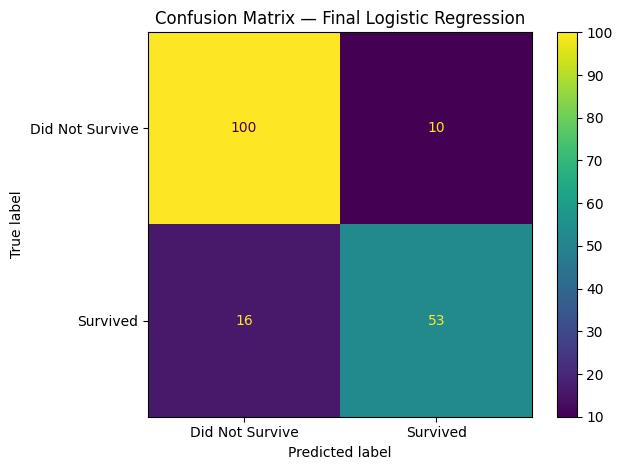

True Negatives:  100
False Positives: 10
False Negatives: 16
True Positives:  53


In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["Did Not Survive", "Survived"],
)
plt.title(f"Confusion Matrix — Final {final_model_name}")
plt.tight_layout()
plt.show()

final_cm = confusion_matrix(y_test, final_predictions)
tn, fp, fn, tp = final_cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

**Interpretation:** True negatives are passengers correctly predicted not to survive, while true positives are passengers correctly predicted to survive. False positives are passengers incorrectly predicted to survive, and false negatives are survivors incorrectly classified as non-survivors. The displayed values correspond to the final selected model, not merely the tuned Random Forest.

## 14.4 Overfitting Check for the Final Selected Model

In [22]:
final_train_predictions = final_model.predict(X_train)
final_train_f1 = f1_score(y_train, final_train_predictions)
final_test_f1 = f1_score(y_test, final_predictions)
final_f1_difference = final_train_f1 - final_test_f1

print(f"Final model: {final_model_name}")
print(f"Training F1: {final_train_f1:.4f}")
print(f"Testing F1:  {final_test_f1:.4f}")
print(f"Difference:  {final_f1_difference:.4f}")

Final model: Logistic Regression
Training F1: 0.7698
Testing F1:  0.8030
Difference:  -0.0332


**Interpretation:** A small training–testing F1 difference indicates that the final model generalizes reasonably well. A large positive difference would suggest overfitting. The conclusion below reports the actual difference produced by the selected final model.

# 15. New Passenger Prediction

In [23]:
new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "male",
    "Age": 25,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 8.05,
    "Embarked": "S",
    "FamilySize": 1,
    "IsAlone": 1,
    "Title": "Mr",
}])

new_passenger = new_passenger[feature_columns]
prediction = final_model.predict(new_passenger)[0]
probability = final_model.predict_proba(new_passenger)[0, 1]
prediction_label = "Survived" if prediction == 1 else "Did Not Survive"

print("Final model used:", final_model_name)
print("Prediction:", prediction_label)
print(f"Survival Probability: {probability:.2%}")

Final model used: Logistic Regression
Prediction: Did Not Survive
Survival Probability: 8.31%


The prediction uses human-readable values such as `male`, `S`, and `Mr`. Encoding, missing-value handling, and scaling are performed automatically by the complete pipeline.

# 16. Save Final Model

In [24]:
MODEL_PATH = Path("titanic_survival_pipeline.joblib")
joblib.dump(final_model, MODEL_PATH)

loaded_model = joblib.load(MODEL_PATH)
loaded_prediction = loaded_model.predict(new_passenger)[0]

print("Saved final model:", final_model_name)
print("Saved path:", MODEL_PATH.resolve())
print("Loaded-model prediction matches:", loaded_prediction == prediction)

Saved final model: Logistic Regression
Saved path: C:\Users\layan\Downloads\archive (2)\archive (1)\titanic_survival_pipeline.joblib
Loaded-model prediction matches: True


# 17. Conclusion and Limitations

The **Logistic Regression** pipeline was selected as the final model. It had the strongest baseline mean cross-validation F1-score and also achieved the best performance on the untouched test set: approximately **85.47% accuracy**, **0.8030 F1-score**, and **0.8794 ROC-AUC**. Random Forest was tuned as required and reached a higher internal cross-validation F1-score of approximately **0.7700**, but its untouched test-set F1-score remained lower than Logistic Regression. Therefore, tuning results were reported without incorrectly replacing the better-performing final model.

The exploratory analysis showed that **gender, passenger class, embarkation port, age, and family-related characteristics** are associated with survival. The engineered `Title` feature was retained after comparison because it maintained or improved cross-validation performance.

### Limitations
- The dataset is small and represents one historical event.
- Several original fields contain missing data, especially `Cabin`.
- Relationships are observational and should not be interpreted as causal.
- Performance may vary with another sample or validation strategy.

### Future work
Possible extensions include threshold tuning, probability calibration, fairness analysis, feature-importance or SHAP explanations, and a small Streamlit interface.